# NYSE TAQ Sample Data Walkthrough

This notebook documents my first pass through the NYSE TAQ sample files.

1. what data I downloaded,
2. what each data type means,
3. what initial features I built



| File type | What it means | What we can do with it |
|---|---|---|
| Symbol lookup file | A dictionary of tickers and company/security metadata | Define a clean universe before feature engineering |
| Quote updates | Best bid and ask updates through the day | Build spread, liquidity, mid-price, and depth features |
| Trade records | Actual executed trades | Build volume, VWAP, trade count, and trade-size features |
| Full-day consolidated trades | Trades across venues for a whole day | Build intraday volume and volatility profiles |


In [1]:
from pathlib import Path
import gzip
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = Path('../data/nyse_taq_samples')
RESEARCH_DIR = Path('.')

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)

## 1. Files downloaded locally

These are the representative files downloaded from the NYSE historical sample site.

In [2]:
downloaded = {
    'Reference master': DATA_DIR / 'EQY_US_ALL_REF_MASTER_20260102.gz',
    'NYSE BBO quotes, hour 1': DATA_DIR / 'EQY_US_TAQ_NYSE_BBO_1_20231002.gz',
    'NYSE venue trades': DATA_DIR / 'EQY_US_TAQ_NYSE_TRADES_20231002.gz',
    'Consolidated full-day trades': DATA_DIR / 'EQY_US_ALL_TRADE_20260102.gz',
}

file_rows = []
for label, path in downloaded.items():
    file_rows.append({
        'label': label,
        'file': path.name,
        'exists': path.exists(),
        'size_gb': path.stat().st_size / 1e9 if path.exists() else np.nan,
    })
pd.DataFrame(file_rows)

,label,file,exists,size_gb
0,Reference master,EQY_US_ALL_REF_MASTER_20260102.gz,True,0.000410
1,"NYSE BBO quotes, hour 1",EQY_US_TAQ_NYSE_BBO_1_20231002.gz,True,1.657498
2,NYSE venue trades,EQY_US_TAQ_NYSE_TRADES_20231002.gz,True,0.100126
3,Consolidated full-day trades,EQY_US_ALL_TRADE_20260102.gz,True,3.234098


In [3]:
def peek_gz(path, n=3):
    with gzip.open(path, 'rt', encoding='latin-1', errors='replace') as f:
        return [next(f).strip() for _ in range(n)]

for label, path in downloaded.items():
    print(f'\n--- {label}: {path.name} ---')
    for line in peek_gz(path, 3):
        print(line[:300])


--- Reference master: EQY_US_ALL_REF_MASTER_20260102.gz ---
Symbol|Security_Description|CUSIP|Security_Type|SIP_Symbol|Old_Symbol|Test_Symbol_Flag|Listed_Exchange|Tape|Unit_Of_Trade|Round_Lot|NYSE_Industry_Code|Shares_Outstanding|Halt_Delay_Reason|Specialist_Clearing_Agent|Specialist_Clearing_Number|Specialist_Post_Number|Specialist_Panel|TradedOnNYSEMKT|Tra
A|Agilent Technologies Inc.|00846U101|A|A||N|N|A|1|100|114A|283.5||G|5|8|I|1|1|1|1|0|1|1|1|1|1|1|0|1|1|1|1||19991118|0|1|1|1
AA|Alcoa Corporation|013872106|A|AA||N|N|A|1|100|130A|258.96||G|5|8|U|1|1|1|1|0|1|1|1|1|1|1|0|1|1|1|1||20161018|0|1|1|0

--- NYSE BBO quotes, hour 1: EQY_US_TAQ_NYSE_BBO_1_20231002.gz ---
3,2,BKD,1,58,N,C,100,4.14,0,0,N,.0001,1
34,4,00:28:41.057267806,BKD,1,P,~,,,,,,~,P
3,5,AB,1,58,N,C,100,30.35,0,0,N,.0001,1

--- NYSE venue trades: EQY_US_TAQ_NYSE_TRADES_20231002.gz ---
3,2,WMB,1,58,N,C,100,33.69,0,0,N,.0001,1
34,4,00:28:41.056404017,WMB,1,P,~,,,,,,~,P
3,5,MA,1,58,N,C,100,395.91,0,0,N,.0001,1

--- Consolida

## 2. Reference master: the ticker dictionary

The reference master answers: **what is this symbol?**

Example: if the trade file says `AAPL`, the reference master is the lookup table that says it is Apple Inc. and gives metadata such as CUSIP and security flags.

It does **not** contain intraday prices, trades, or quote updates. It is useful for filtering the universe before feature engineering.

In [4]:
ref_path = downloaded['Reference master']
ref = pd.read_csv(ref_path, sep='|', dtype=str, encoding='latin-1')
print('Rows:', len(ref), 'Columns:', ref.shape[1])
ref[['Symbol', 'Security_Description', 'CUSIP', 'Security_Type']].head(12)

Rows: 12181 Columns: 40


,Symbol,Security_Description,CUSIP,Security_Type
0,A,Agilent Technologies Inc.,00846U101,A
1,AA,Alcoa Corporation,013872106,A
2,AAA,Alternative Access First Priority CLO Bond ETF,46144X610,ETF
3,AAAA,Amplius Aggressive Asset Allocation ETF,02072Q689,ETF
4,AAAC,Columbia AAA CLO ETF,19761L763,ETF
5,AAAU,Goldman Sachs Physical Gold ETF Shares,38150K103,ETF
6,AACB,Artius II Acquisition Inc. Class A Ordinary Sh...,G0509J115,A
7,AACB R,Artius II Acquisition Inc. Rights,G0509J123,D
8,AACB U,Artius II Acquisition Inc. Units,G0509J107,R
9,AACG,ATA Creativity Global American Depositary Shares,00211V106,H


### Why this matters

For a real TAQ project, the reference master helps us define a clean universe:

- include common stocks and ETFs,
- exclude odd instruments when necessary,
- map tickers to company names/CUSIPs,
- know which symbols are active on which venues.

In an email, this can be described simply as **the symbol lookup file**.

## 3. NYSE BBO quotes: top-of-book liquidity

BBO means **Best Bid and Offer**. Each row is a quote update from NYSE's top of book:

- bid price = best price someone is willing to buy,
- ask price = best price someone is willing to sell,
- spread = ask minus bid,
- mid-price = average of bid and ask,
- depth imbalance = whether more displayed size is on the bid side or ask side.

This file is useful for liquidity features.

In [5]:
def sample_bbo(path, max_rows=250_000):
    rows = []
    with gzip.open(path, 'rt', encoding='latin-1', errors='replace') as f:
        for line in f:
            parts = line.strip().split(',')
            if len(parts) < 9 or parts[0] != '140':
                continue
            try:
                rows.append({
                    'timestamp': parts[2],
                    'symbol': parts[3],
                    'quote_condition': parts[4],
                    'ask_px': float(parts[5]) if parts[5] else np.nan,
                    'ask_sz': float(parts[6]) if parts[6] else np.nan,
                    'bid_px': float(parts[7]) if parts[7] else np.nan,
                    'bid_sz': float(parts[8]) if parts[8] else np.nan,
                })
            except ValueError:
                continue
            if len(rows) >= max_rows:
                break
    df = pd.DataFrame(rows)
    valid = (df['bid_px'] > 0) & (df['ask_px'] > df['bid_px'])
    df = df.loc[valid].copy()
    df['mid'] = (df['bid_px'] + df['ask_px']) / 2
    df['spread_bps'] = (df['ask_px'] - df['bid_px']) / df['mid'] * 10000
    df['depth_imbalance'] = (df['bid_sz'] - df['ask_sz']) / (df['bid_sz'] + df['ask_sz'])
    return df

bbo_sample = sample_bbo(downloaded['NYSE BBO quotes, hour 1'])
bbo_sample.head()

,timestamp,symbol,quote_condition,ask_px,ask_sz,bid_px,bid_sz,mid,spread_bps,depth_imbalance
1,07:00:00.003904602,DTD,5,60.39,1600.0,59.91,1600.0,60.15,79.800499,0.0
3,07:00:00.003923398,DLN,5,61.71,1600.0,61.21,1600.0,61.46,81.353726,0.0
5,07:00:00.003980439,IEO,5,98.83,1000.0,96.93,1000.0,97.88,194.115243,0.0
7,07:00:00.003982883,FDN,5,160.66,600.0,159.36,600.0,160.01,81.244922,0.0
9,07:00:00.007752468,DIG,5,44.52,1100.0,42.80,1100.0,43.66,393.953275,0.0


In [6]:
bbo_summary = bbo_sample.groupby('symbol').agg(
    quote_updates=('mid', 'count'),
    avg_spread_bps=('spread_bps', 'mean'),
    avg_depth_imbalance=('depth_imbalance', 'mean'),
    avg_bid_size=('bid_sz', 'mean'),
    avg_ask_size=('ask_sz', 'mean'),
).sort_values('quote_updates', ascending=False).head(12)
bbo_summary

,quote_updates,avg_spread_bps,avg_depth_imbalance,avg_bid_size,avg_ask_size
symbol,,,,,
DIA,29179,19.744067,-0.022584,1009.510264,951.115528
IVV,23921,18.316502,0.004636,1105.451277,1092.914176
BLDP,20710,209.191912,0.266284,2029.570256,857.749879
IWM,10518,12.409100,-0.016559,496.501236,537.012740
BRZU,10093,397.561975,0.000142,100.099079,100.000000
BZQ,9655,397.531494,0.000173,100.072501,100.020715
AAPL,8144,169.613357,-0.000409,100.208743,100.331532
FEMY,6436,131.546695,0.002572,131.044127,129.070851
AZN,6148,20.085041,0.080061,552.586207,482.254392


## 4. NYSE venue trades

The NYSE trades file contains actual trades on the NYSE venue. This is different from quote data: a quote is an available price, while a trade is an executed transaction.

Useful trade features include volume, trade count, average trade size, VWAP, and sale-condition indicators.

In [7]:
def sample_nyse_trades(path, max_rows=250_000):
    rows = []
    with gzip.open(path, 'rt', encoding='latin-1', errors='replace') as f:
        for line in f:
            parts = line.strip().split(',')
            if len(parts) < 9 or parts[0] != '3':
                continue
            try:
                rows.append({
                    'symbol': parts[2],
                    'sale_condition': parts[6] if len(parts) > 6 else '',
                    'size': int(parts[7]) if parts[7] else np.nan,
                    'price': float(parts[8]) if parts[8] else np.nan,
                })
            except ValueError:
                continue
            if len(rows) >= max_rows:
                break
    return pd.DataFrame(rows)

nyse_trades_sample = sample_nyse_trades(downloaded['NYSE venue trades'])
nyse_trades_sample.head()

,symbol,sale_condition,size,price
0,WMB,C,100,33.69
1,MA,C,100,395.91
2,BKD,C,100,4.14
3,AB,C,100,30.35
4,TDG,C,100,843.13


In [8]:
nyse_trade_summary = nyse_trades_sample.groupby('symbol').agg(
    trades=('price', 'count'),
    volume=('size', 'sum'),
    avg_trade_size=('size', 'mean'),
    avg_price=('price', 'mean'),
).sort_values('trades', ascending=False).head(12)
nyse_trade_summary

,trades,volume,avg_trade_size,avg_price
symbol,,,,
A,1,100,100.0,111.5950
ONCT,1,100,100.0,0.3033
OP,1,100,100.0,2.9300
OPA,1,100,100.0,10.6884
OPA U,1,100,100.0,10.5500
OPA WS,1,100,100.0,0.0394
OPAD,1,100,100.0,9.7600
OPAD WS,1,100,100.0,0.0151
OPAL,1,100,100.0,8.2000


## 5. Consolidated full-day trades

The consolidated trades file is easier to explain: it has a header row and contains trades reported across venues for the full day.

This file is very useful because it gives a full-day view of trading activity.

In [9]:
consolidated_path = downloaded['Consolidated full-day trades']
with gzip.open(consolidated_path, 'rt', encoding='latin-1', errors='replace') as f:
    header = next(f).strip().split('|')
    first_rows = [next(f).strip().split('|') for _ in range(5)]

print(header)
pd.DataFrame(first_rows, columns=header).head()

['Time', 'Exchange', 'Symbol', 'Sale Condition', 'Trade Volume', 'Trade Price', 'Trade Stop Stock Indicator', 'Trade Correction Indicator', 'Sequence Number', 'Trade Id', 'Source of Trade', 'Trade Reporting Facility', 'Participant Timestamp', 'Trade Reporting Facility TRF Timestamp', 'Trade Through Exempt Indicator']


,Time,Exchange,Symbol,Sale Condition,Trade Volume,Trade Price,Trade Stop Stock Indicator,Trade Correction Indicator,Sequence Number,Trade Id,Source of Trade,Trade Reporting Facility,Participant Timestamp,Trade Reporting Facility TRF Timestamp,Trade Through Exempt Indicator
0,041930940885651,P,A,TI,1,137.29,N,00,4005,52983525029425,C,,041930940851589,,0
1,041930945218960,P,A,TI,6,137.19,N,00,4006,52983525029426,C,,041930945195853,,0
2,044637030120042,T,A,TI,1,136.21,N,00,4368,62879130799192,C,,044637029763969,,0
3,050732481979841,K,A,TI,1,137,N,00,4648,52983525028952,C,,050732481723000,,0
4,052359160985600,P,A,TI,5,136.21,N,00,4904,52983525033806,C,,052359160960394,,0


## 6. Processed feature outputs already produced

The scripts in the research folder produced CSVs and plots. The most interpretable one is the full-day consolidated trade bars file. Each row is one symbol-minute.

In [10]:
trade_bars_path = RESEARCH_DIR / 'taq_consolidated_trade_bars.csv'
trade_bars = pd.read_csv(trade_bars_path)
trade_bars.head()

,time_bin,total_volume,trade_count,avg_price,vwap,open_price,high_price,low_price,close_price,avg_volume,max_volume,symbol,minute_return,minute_range,realized_var,dollar_volume,time_of_day
0,240,1788,75,273.070667,273.176326,272.17,273.30,272.17,273.08,23.840000,165,AAPL,0.003338,41.518169,1.114172e-05,488439.27,04:00
1,241,791,39,273.448974,273.410164,273.29,273.90,273.24,273.50,20.282051,100,AAPL,0.000768,24.150170,5.900075e-07,216267.44,04:01
2,242,12,6,273.295000,273.302500,273.25,273.32,273.25,273.32,2.000000,4,AAPL,0.000256,2.561757,6.560916e-08,3279.63,04:02
3,243,66,8,273.315000,273.319091,273.32,273.32,273.30,273.30,8.250000,22,AAPL,-0.000073,0.731743,5.354870e-09,18039.06,04:03
4,244,74,10,273.358000,273.371622,273.34,273.42,273.32,273.40,7.400000,30,AAPL,0.000219,3.658447,4.817268e-08,20229.50,04:04


In [11]:
summary = trade_bars.groupby('symbol').agg(
    total_volume=('total_volume', 'sum'),
    total_trades=('trade_count', 'sum'),
    avg_trade_size=('avg_volume', 'mean'),
    vwap=('vwap', lambda x: np.average(x, weights=trade_bars.loc[x.index, 'total_volume'])),
    open_price=('open_price', 'first'),
    close_price=('close_price', 'last'),
    realized_var=('realized_var', 'sum'),
).reset_index()
summary['daily_return_pct'] = 100 * np.log(summary['close_price'] / summary['open_price'])
summary.sort_values('total_trades', ascending=False)

,symbol,total_volume,total_trades,avg_trade_size,vwap,open_price,close_price,realized_var,daily_return_pct
5,TSLA,89922555,1865256,56.745168,443.864800,458.63,441.4900,0.000624,-3.808842
4,SPY,93459938,1251790,652.864504,682.980148,685.32,683.1700,0.000086,-0.314215
3,QQQ,62536678,1088614,76.462157,614.899592,617.38,613.6900,0.000146,-0.599480
2,MSFT,29352772,716532,41.511162,474.412569,487.00,473.3000,0.009800,-2.853469
0,AAPL,48835599,642197,103.375618,271.727426,272.17,270.9607,0.000227,-0.445308
1,IWM,42081335,351337,870.008111,247.682018,247.70,248.7800,0.000242,0.435064


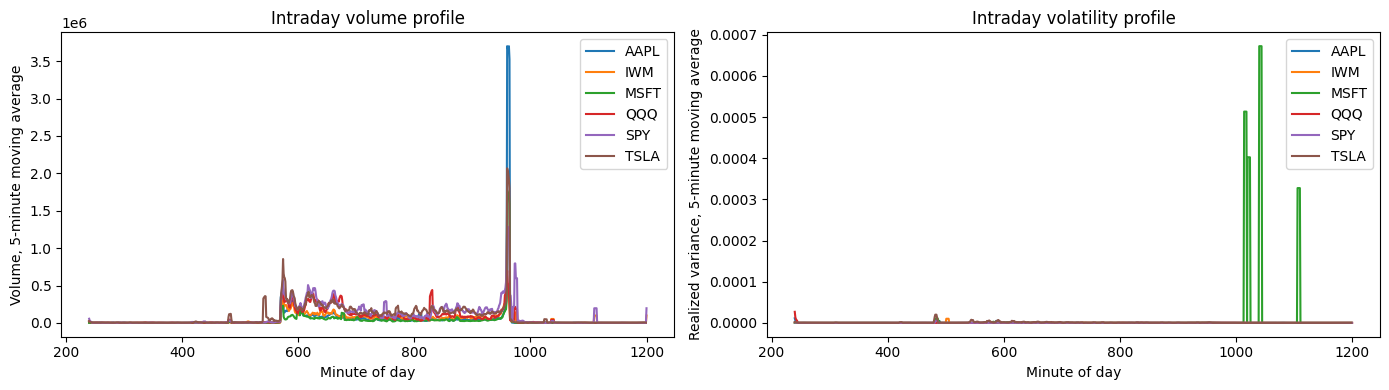

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for symbol, group in trade_bars.groupby('symbol'):
    group = group.sort_values('time_bin')
    axes[0].plot(group['time_bin'], group['total_volume'].rolling(5, min_periods=1).mean(), label=symbol)
    axes[1].plot(group['time_bin'], group['realized_var'].rolling(5, min_periods=1).mean(), label=symbol)
axes[0].set_title('Intraday volume profile')
axes[0].set_xlabel('Minute of day')
axes[0].set_ylabel('Volume, 5-minute moving average')
axes[1].set_title('Intraday volatility profile')
axes[1].set_xlabel('Minute of day')
axes[1].set_ylabel('Realized variance, 5-minute moving average')
axes[0].legend()
axes[1].legend()
plt.tight_layout()

## 7. Main findings so far

From the downloaded samples:

1. The site contains enough different feeds for serious feature engineering: trades, top-of-book quotes, full order book, and auction imbalances.
2. The reference master is just the symbol lookup table, not a predictive dataset by itself.
3. BBO data gives liquidity features such as bid-ask spread, quote update intensity, and displayed depth imbalance.
4. Consolidated trades give full-day volume, VWAP, trade count, average trade size, and intraday volume/volatility profiles.
5. A single hour of BBO data is too short for reliable prediction, but it is enough to understand the schema and build the pipeline.
6. The full-day consolidated trades file is already useful for constructing intraday curves.

## 8. Where nonlinear dimension reduction could enter

Professor Schafer mentioned nonlinear dimension reduction. A natural setup is:

- Convert each symbol-day into a high-dimensional intraday curve.
- Example: a 390-dimensional vector of minute-by-minute volume, spread, volatility, or order-flow imbalance.
- Compare PCA with nonlinear methods such as Isomap, diffusion maps, UMAP, or autoencoders.
- Ask whether nonlinear methods uncover regimes: opening behavior, stress days, liquidity shocks, ETF vs single-name structure, etc.

This is more promising than applying nonlinear dimension reduction to individual raw quote rows. The object should be a **curve/profile**, not a single message.

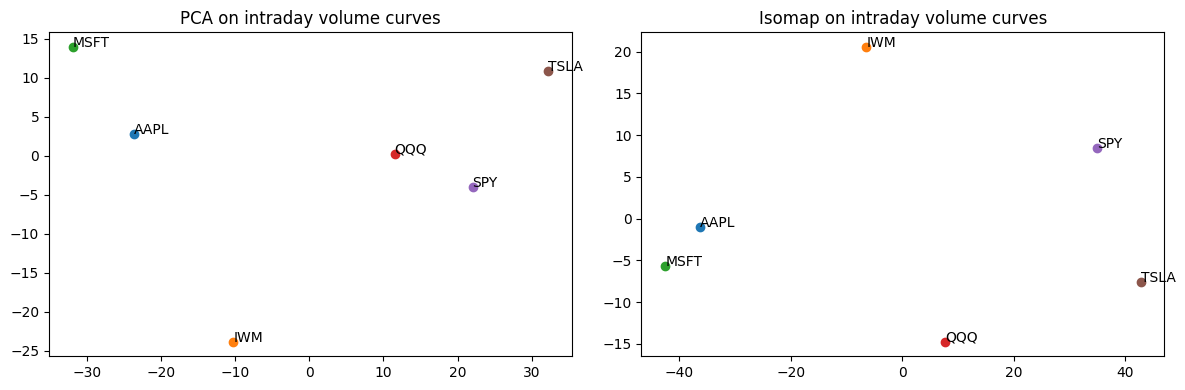

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import Isomap

volume_curve = trade_bars.pivot_table(index='symbol', columns='time_bin', values='total_volume', fill_value=0)
X = np.log1p(volume_curve.values)
X_scaled = StandardScaler().fit_transform(X)

pca_emb = PCA(n_components=2, svd_solver='full').fit_transform(X_scaled)
isomap_emb = Isomap(n_neighbors=min(3, len(volume_curve) - 1), n_components=2).fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, symbol in enumerate(volume_curve.index):
    axes[0].scatter(pca_emb[i, 0], pca_emb[i, 1])
    axes[0].text(pca_emb[i, 0], pca_emb[i, 1], symbol)
    axes[1].scatter(isomap_emb[i, 0], isomap_emb[i, 1])
    axes[1].text(isomap_emb[i, 0], isomap_emb[i, 1], symbol)
axes[0].set_title('PCA on intraday volume curves')
axes[1].set_title('Isomap on intraday volume curves')
plt.tight_layout()

### Important caveat

The plot above is only a demonstration because we currently have only six symbols from one full-day trade file. A real test would need many symbols and/or many days.

But this gives a concrete answer to the professor's question: **TAQ can generate high-dimensional intraday profiles, and those profiles are natural inputs for nonlinear dimension reduction.**

## 9. Email-level summary

A plain-English version to tell Professor Schafer:

> I looked through the NYSE TAQ samples and downloaded representative files. The main useful pieces are a symbol lookup file, top-of-book quote updates, and trade files. I wrote parsers and built initial features such as spreads, quote update intensity, depth imbalance, volume, VWAP, and intraday volume/volatility profiles. The data looks promising for feature engineering. In particular, one promising nonlinear-dimension-reduction example is to treat each symbol/day as an intraday curve and compare PCA with nonlinear embeddings on those curves. I can walk through the notebook and next steps when we meet.